In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
   area     price
0  7420  13300000
1  8960  12250000
2  9960  12250000
3  7500  12215000
4  7420  11410000


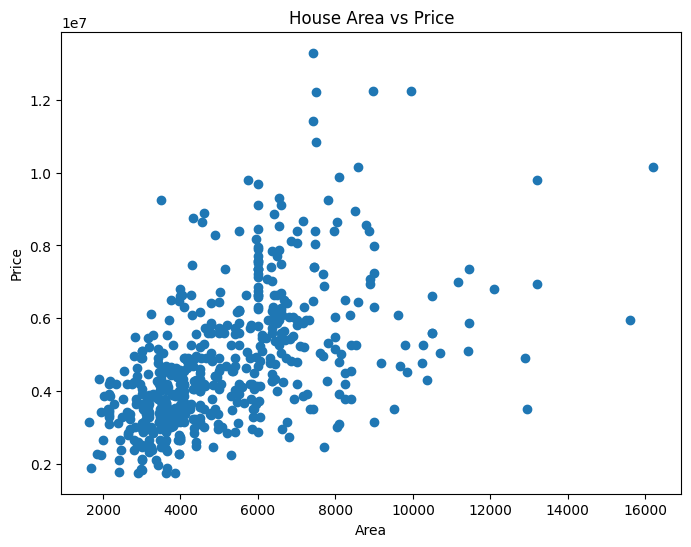

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv")

# Check columns
print(df.columns)

# Keep only area and price
df = df[['area', 'price']]

# Remove missing values if any
df = df.dropna()

# Preview
print(df.head())

# Extract X and y
X = df['area'].values
y = df['price'].values

import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(8,6))
plt.scatter(X, y)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Area vs Price")

plt.show()

X_original = df['area'].values
y_original = df['price'].values

X_mean = X_original.mean()
X_std = X_original.std()

y_mean = y_original.mean()
y_std = y_original.std()

X = (X_original - X_mean) / X_std
y = (y_original - y_mean) / y_std



In [3]:
def loss_function(weight, bias, X, y):

    total_error = 0

    for i in range(X.size):

        predicted = (weight * X[i]) + bias
        actual = y[i]

        total_error += (predicted - actual) ** 2

    loss = total_error / X.size

    return loss

In [4]:
def LinearRegression(
    new_area,
    weight,
    bias,
    X,
    y,
    X_mean,
    X_std,
    y_mean,
    y_std
):

    # Normalize incoming area
    normalized_area = (new_area - X_mean) / X_std

    # Predict normalized output
    normalized_prediction = (
        weight * normalized_area
    ) + bias

    # Convert back to original scale
    predicted_price = (
        normalized_prediction * y_std
    ) + y_mean

    print(f"Predicted price: {predicted_price}")

    # Plot original dataset
    plt.scatter(X_original, y_original)

    # Plot predicted point
    plt.scatter(new_area, predicted_price)

    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.title("House Area vs Price")

    plt.show()

    return predicted_price


In [5]:
print(X[2]) 
print(y[2]) #for reference

2.218232407225722
4.004484046345774


In [6]:
import math
def learn_function(X, y, weight, bias, learning_rate, epochs):

    n = X.size

    best_weight = weight
    best_bias = bias
    best_loss = float('inf')

    for epoch in range(epochs):

        d_weight = 0
        d_bias = 0

        # Compute gradients
        for i in range(n):

            predicted = (weight * X[i]) + bias
            actual = y[i]

            error = predicted - actual

            d_weight += error * X[i]
            d_bias += error

        # Average gradients
        d_weight = (2 / n) * d_weight
        d_bias = (2 / n) * d_bias

        # Update parameters
        weight = weight - (learning_rate * d_weight)
        bias = bias - (learning_rate * d_bias)

        # Compute loss
        loss = loss_function(weight, bias, X, y)

        # Stop training if invalid
        if math.isnan(loss) or math.isinf(loss):

            print("Training stopped.")
            print("Loss became NaN or Inf.")
            break

        # Save best parameters
        if loss < best_loss:

            best_loss = loss
            best_weight = weight
            best_bias = bias

        print(f"Epoch {epoch + 1}")
        print(f"Weight: {weight}")
        print(f"Bias: {bias}")
        print(f"Loss: {loss}")
        print("----------------------")

    print(f"Best Loss: {best_loss}")

    return best_weight, best_bias
  

In [7]:
initial_weight = 0
initial_bias = 0

learning_rate = 0.001
epochs = 100

final_weight, final_bias = learn_function(
    X,
    y,
    initial_weight,
    initial_bias,
    learning_rate,
    epochs
)

Epoch 1
Weight: 0.0010719946915561612
Bias: -7.936566796219469e-19
Loss: 0.9988519765538947
----------------------
Epoch 2
Weight: 0.002141845393729209
Bias: -1.3192301481600945e-18
Loss: 0.9977085406094783
----------------------
Epoch 3
Weight: 0.0032095563944979097
Bias: -2.1658515959292967e-18
Loss: 0.9965696738350964
----------------------
Epoch 4
Weight: 0.004275131973265074
Bias: -1.6777608863876681e-18
Loss: 0.9954353579723476
----------------------
Epoch 5
Weight: 0.005338576400874704
Bias: -1.619092220132247e-18
Loss: 0.9943055748357839
----------------------
Epoch 6
Weight: 0.006399893939629114
Bias: -9.908485856471126e-19
Loss: 0.993180306312635
----------------------
Epoch 7
Weight: 0.007459088843306016
Bias: -4.1556971930923337e-19
Loss: 0.9920595343625005
----------------------
Epoch 8
Weight: 0.008516165357175564
Bias: 2.2489655397911382e-19
Loss: 0.9909432410170845
----------------------
Epoch 9
Weight: 0.009571127718017373
Bias: 7.317286430190019e-19
Loss: 0.9898314083

Predicted price: 5141348.46661767


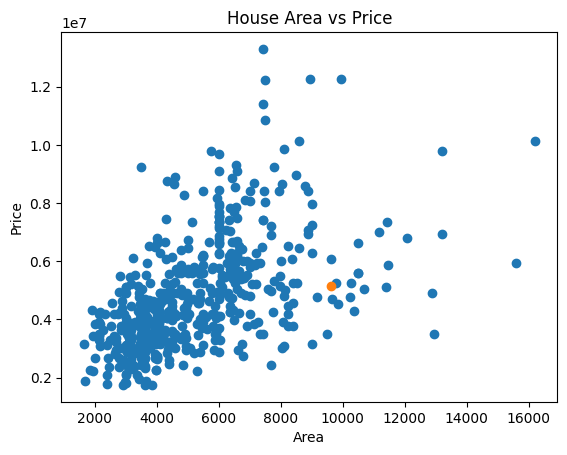

Final Predicted Price: 5141348.46661767


In [8]:
prediction = LinearRegression(
    new_area=9620,
    weight=final_weight,
    bias=final_bias,
    X=X,
    y=y,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=y_mean,
    y_std=y_std
)

print(f"Final Predicted Price: {prediction}")

In [9]:
#Since area alone is very noisy. The prediction is fair.